# Coffee augmentation demo

Small notebook for checking the standalone augmentation module, both for single-image previews and for offline dataset generation.

In [1]:
from pathlib import Path
import csv
import sys

from PIL import Image, ImageOps, ImageDraw

current = Path.cwd().resolve()
project_root = None
for candidate in [current, *current.parents]:
    if (candidate / "src").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError("Could not locate project root")

sys.path.insert(0, str(project_root / "src"))

from transforms import AugmentationConfig, CoffeeAugmentor, load_image, set_seed

In [2]:
config = AugmentationConfig(
    horizontal_flip_prob=0.5,
    vertical_flip_prob=0.1,
    rotation_prob=0.8,
    affine_prob=0.8,
    perspective_prob=0.3,
    blur_prob=0.25,
    noise_prob=0.25,
    jpeg_prob=0.15,
    cutout_prob=0.1,
)

augmentor = CoffeeAugmentor(config=config, seed=42)
set_seed(42)

IMG_6071.png
('horizontal_flip', 'vertical_flip', 'zoom_crop', 'rotation', 'affine', 'brightness', 'contrast', 'sharpness', 'blur')


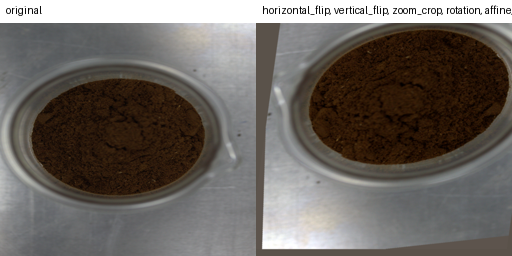

In [18]:
def make_contact_sheet(images, titles=None, tile_size=(256, 256), cols=3):
    titles = titles or [""] * len(images)
    thumb_w, thumb_h = tile_size
    rows = (len(images) + cols - 1) // cols
    sheet = Image.new("RGB", (cols * thumb_w, rows * thumb_h), "white")
    draw = ImageDraw.Draw(sheet)

    for index, (image, title) in enumerate(zip(images, titles)):
        row = index // cols
        col = index % cols
        thumb = ImageOps.fit(image.convert("RGB"), tile_size, method=Image.Resampling.BICUBIC)
        x = col * thumb_w
        y = row * thumb_h
        sheet.paste(thumb, (x, y))
        if title:
            draw.rectangle([x, y, x + thumb_w, y + 22], fill=(255, 255, 255))
            draw.text((x + 6, y + 4), title, fill=(0, 0, 0))

    return sheet

labels_csv = project_root / "data" / "labels" / "train.csv"
images_dir = project_root / "data" / "images"

with labels_csv.open("r", encoding="utf-8-sig", newline="") as handle:
    reader = csv.reader(handle, delimiter=";")
    header = next(reader)
    first_row = next(reader)

sample_name = first_row[0]
sample_path = images_dir / sample_name
original = load_image(sample_path)
augmented, ops = augmentor.augment(original, return_ops=True)

sheet = make_contact_sheet(
    [original, augmented],
    ["original", ", ".join(ops) if ops else "augmented"],
    cols=2,
)

print(sample_name)
print(ops)
sheet

In [4]:
output_dir = project_root / "data" / "augmented_preview"
output_csv = output_dir / "augmented_preview.csv"

results = augmentor.expand_csv_dataset(
    labels_csv,
    images_dir,
    output_dir,
    n_new_images=10,
    output_csv_path=output_csv,
)

print(f"generated: {len(results)}")
print(f"saved to: {output_dir}")
print(f"csv: {output_csv}")

generated: 10
saved to: C:\Users\erny\PycharmProjects\coffee-grind-analysis\data\augmented_preview
csv: C:\Users\erny\PycharmProjects\coffee-grind-analysis\data\augmented_preview\augmented_preview.csv
